## Load data

In [1]:
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

from pymutspec.draw import plot_mutspec12
from pymutspec.annotation import CodonAnnotation
from pymutspec.constants import possible_codons
from pymutspec.io import read_genbank_ref

from scipy.spatial.distance import euclidean, cityblock, pdist, squareform
from scipy.stats import chisquare, ks_2samp, pearsonr, spearmanr, uniform
from scipy.special import kl_div
from sklearn.metrics import mean_squared_error, r2_score
import tqdm
import pingouin as pg

from utils import (
    amino_acid_codes, alphabet, cdn_spectrum_to_matrix, 
    nuc_spectrum_to_matrix, collect_possible_changes,
    get_equilibrium_probabilities, plot_exp_heatmap,
    prepare_aa_subst, plot_aa_eq_freqs, prepare_exp_aa_subst,
    calc_metrics,weighted_average_percentage_error, get_equilibrium_freqs
)

In [2]:
coda = CodonAnnotation(1)

## Prepare the data

In [6]:
aa_fitness = pd.read_csv('./data/bloom_etal/aa_fitness.csv')
aa_fitness

,gene,aa_site,aa,fitness,expected_count,aa_differs_among_clade_founders,subset_of_ORF1ab
0,E,1,I,-7.1032,607.410,False,False
1,E,1,K,-3.5840,17.508,False,False
2,E,1,L,-4.3124,36.811,False,False
3,E,1,M,0.0000,844.230,False,False
4,E,1,R,-3.1560,11.238,False,False
...,...,...,...,...,...,...,...
122158,nsp9,113,K,-3.4869,48.529,False,True
122159,nsp9,113,L,-2.8511,25.461,False,True
122160,nsp9,113,P,-2.0669,11.350,False,True
122161,nsp9,113,Q,0.0000,925.030,False,True


In [14]:
aa_fitness_ref = aa_fitness.query('fitness == 0 & ~subset_of_ORF1ab').set_index(['gene', 'aa_site'])
aa_fitness_ref

aa  fitness  expected_count  aa_differs_among_clade_founders  \
gene aa_site                                                                
E    1        M      0.0          844.23                            False   
     2        Y      0.0          302.17                            False   
     3        S      0.0          873.08                            False   
     4        F      0.0          287.04                            False   
     5        V      0.0          718.24                            False   
...          ..      ...             ...                              ...   
S    1268     V      0.0          718.24                            False   
     1269     K      0.0          288.77                            False   
     1270     L      0.0          176.40                            False   
     1271     H      0.0          916.97                            False   
     1272     Y      0.0          302.17                            False   

              subset_of_ORF1ab  
gene aa_site                    
E    1                   False  
     2                   False  
     3                   False  
     4                   False  
     5                   False  
...                        ...  
S    1268                False  
     1269                False  
     1270                False  
     1271                False  
     1272                False  

[9741 rows x 5 columns]

In [15]:
# ref fitness is 0
aa_fitness_ref.fitness.describe()

count    9741.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: fitness, dtype: float64

In [18]:
site_fitnesses = aa_fitness.query('~subset_of_ORF1ab').pivot(index=['gene', 'aa_site'], columns='aa', values='fitness').replace(0, np.nan)
site_fitnesses

aa                 *        A       C       D       E       F        G  \
gene aa_site                                                             
E    1           NaN      NaN     NaN     NaN     NaN     NaN      NaN   
     2       -3.7819      NaN -5.1893 -3.1560     NaN -2.8511      NaN   
     3       -4.8805 -0.95878     NaN     NaN     NaN     NaN      NaN   
     4           NaN      NaN -3.1560     NaN     NaN     NaN      NaN   
     5           NaN -2.27390     NaN -3.5840     NaN -2.2231 -2.05740   
...              ...      ...     ...     ...     ...     ...      ...   
S    1268        NaN -0.90241     NaN -3.5840     NaN -2.5549 -0.95878   
     1269    -1.7525      NaN     NaN     NaN -3.2434     NaN      NaN   
     1270    -4.0689      NaN     NaN     NaN     NaN -3.2138      NaN   
     1271        NaN      NaN     NaN -1.9357     NaN     NaN      NaN   
     1272    -1.3252      NaN -3.5798 -3.1560     NaN -1.7525      NaN   

aa                  H        I      K  ...   M       N       P       Q  \
gene aa_site                           ...                               
E    1            NaN -7.10320 -3.584  ... NaN     NaN     NaN     NaN   
     2       -2.27390      NaN    NaN  ... NaN -3.5840     NaN     NaN   
     3            NaN      NaN    NaN  ... NaN     NaN -0.7633     NaN   
     4            NaN -2.48540    NaN  ... NaN     NaN     NaN     NaN   
     5            NaN  0.72401    NaN  ... NaN     NaN     NaN     NaN   
...               ...      ...    ...  ...  ..     ...     ...     ...   
S    1268         NaN -1.26550    NaN  ... NaN     NaN     NaN     NaN   
     1269         NaN -3.94980    NaN  ... NaN -3.2138     NaN -2.0669   
     1270         NaN -2.48540    NaN  ... NaN     NaN     NaN     NaN   
     1271         NaN      NaN    NaN  ... NaN -2.1877 -2.0669 -4.0689   
     1272    -0.49199      NaN    NaN  ... NaN -3.5840     NaN     NaN   

aa                 R       S       T        V   W       Y  
gene aa_site                                               
E    1       -3.1560     NaN -5.1071 -4.09070 NaN     NaN  
     2           NaN -3.1655     NaN      NaN NaN     NaN  
     3           NaN     NaN -1.1861      NaN NaN     NaN  
     4           NaN -3.1612     NaN -3.15600 NaN -1.9745  
     5           NaN     NaN     NaN      NaN NaN     NaN  
...              ...     ...     ...      ...  ..     ...  
S    1268        NaN     NaN     NaN      NaN NaN     NaN  
     1269    -4.0907     NaN -1.5560      NaN NaN     NaN  
     1270        NaN -1.5518     NaN -0.75811 NaN     NaN  
     1271    -2.9920     NaN     NaN      NaN NaN -2.4283  
     1272        NaN -3.1655     NaN      NaN NaN     NaN  

[9741 rows x 21 columns]

In [22]:
aa_fitness.query('fitness == 0 & ~subset_of_ORF1ab').gene.value_counts()

gene
ORF1ab    7023
S         1258
N          414
ORF3a      275
M          221
ORF7a      120
ORF8       119
ORF9b       97
E           75
ORF6        61
ORF7b       41
ORF10       37
Name: count, dtype: int64

In [74]:
ref_sites_df = pd.read_csv('./data/ref_annot.csv')
ref_sites_df['aa'] = ref_sites_df.Codon.apply(coda.translate_codon)
ref_sites_df['aa_site_new'] = (ref_sites_df.PosInGene - 1) // 3 + 1
ref_sites_df = ref_sites_df[ref_sites_df.aa_site_new < 4402].copy()  # only ORF1a 
ref_sites_df

,Pos,Nuc,Context,Strand,Type,gene,PosInGene,PosInCodon,Codon,MutCountTotal,MutCountNonsyn,nt_site,codon_position,aa_site,AA,rate_cat,rate_cat_ns,aa,aa_site_new
0,266,A,GAT,1,mat_peptide,ORF1ab,1,1,ATG,0.0,0.0,NaN,NaN,NaN,Met,0,0,M,1
1,267,T,ATG,1,mat_peptide,ORF1ab,2,2,ATG,2.0,2.0,267.0,2;2,1.0,Met,1,1,M,1
2,268,G,TGG,1,mat_peptide,ORF1ab,3,3,ATG,1.0,1.0,268.0,3;3,1.0,Met,1,1,M,1
3,269,G,GGA,1,mat_peptide,ORF1ab,4,1,GAG,239.0,239.0,269.0,1;1,2.0,Glu,4,4,E,2
4,270,A,GAG,1,mat_peptide,ORF1ab,5,2,GAG,154.0,154.0,270.0,2;2,2.0,Glu,3,3,E,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29255,29670,C,ACA,1,CDS,ORF10,113,2,ACA,687.0,687.0,29670.0,2,38.0,Thr,4,4,T,38
29256,29671,A,CAT,1,CDS,ORF10,114,3,ACA,114.0,1.0,29671.0,3,38.0,Thr,3,1,T,38
29257,29672,T,ATA,1,CDS,ORF10,115,1,TAG,57.0,0.0,NaN,NaN,NaN,*,2,0,*,39
29258,29673,A,TAG,1,CDS,ORF10,116,2,TAG,29.0,0.0,NaN,NaN,NaN,*,2,0,*,39


In [89]:
rates_df = ref_sites_df.dropna().groupby(['gene', 'aa_site_new', 'aa']).rate_cat_ns.median().reset_index().rename(columns={'aa_site_new':'aa_site', 'aa':'ref_aa'}).set_index(['gene', 'aa_site'])
rates_df

ref_aa  rate_cat_ns
gene aa_site                    
E    1            M          1.0
     2            Y          1.0
     3            S          2.5
     4            F          2.0
     5            V          2.5
...             ...          ...
S    1269         K          1.0
     1270         L          1.0
     1271         H          2.0
     1272         Y          2.0
     1273         T          3.0

[6944 rows x 2 columns]

### The dataset

In [127]:
total_data = site_fitnesses.join(rates_df, how='inner').set_index(['ref_aa', 'rate_cat_ns'], append=True).mean(axis=1).rename('mean_fitness').reset_index()
total_data['is_gainer'] = total_data.ref_aa.isin(['F', 'L', 'S', 'I', 'Y', 'V'])
total_data

,gene,aa_site,ref_aa,rate_cat_ns,mean_fitness,is_gainer
0,E,1,M,1.0,-4.558900,False
1,E,2,Y,1.0,-3.428814,True
2,E,3,S,2.5,-2.056856,True
3,E,4,F,2.0,-2.383348,True
4,E,5,V,2.5,-1.498047,True
...,...,...,...,...,...,...
6871,S,1268,V,2.5,-1.784048,True
6872,S,1269,K,1.0,-2.839014,False
6873,S,1270,L,1.0,-2.415602,True
6874,S,1271,H,2.0,-2.526186,False


<Axes: >

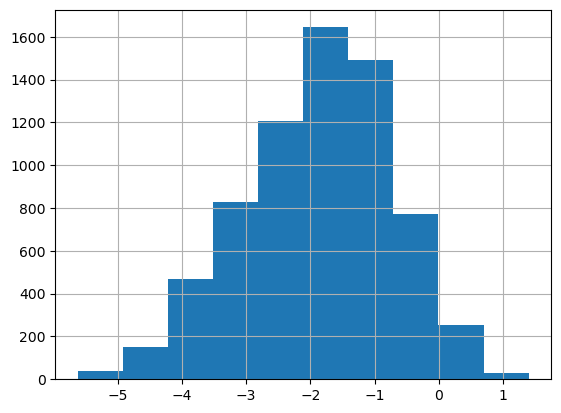

In [139]:
total_data.mean_fitness.hist()

<Axes: xlabel='is_gainer', ylabel='rate_cat_ns'>

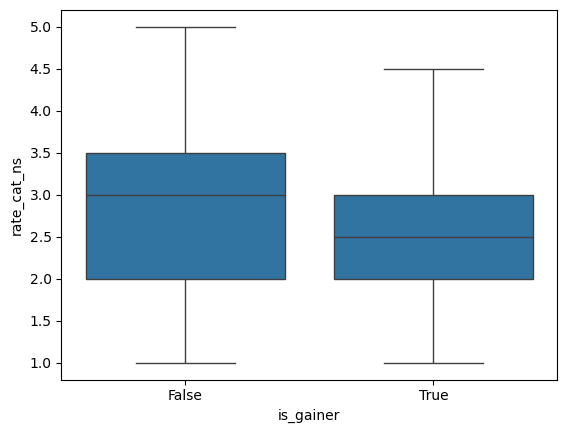

In [156]:
sns.boxplot(y='rate_cat_ns', x='is_gainer', data=total_data)

<Axes: xlabel='rate_cat_ns', ylabel='mean_fitness'>

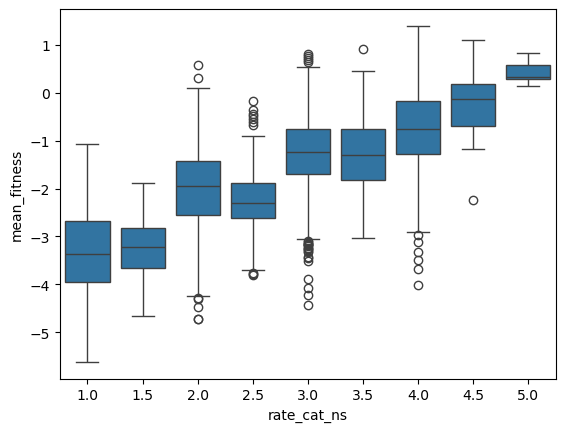

In [153]:
sns.boxplot(x='rate_cat_ns', y='mean_fitness', data=total_data)

<Axes: xlabel='is_gainer', ylabel='mean_fitness'>

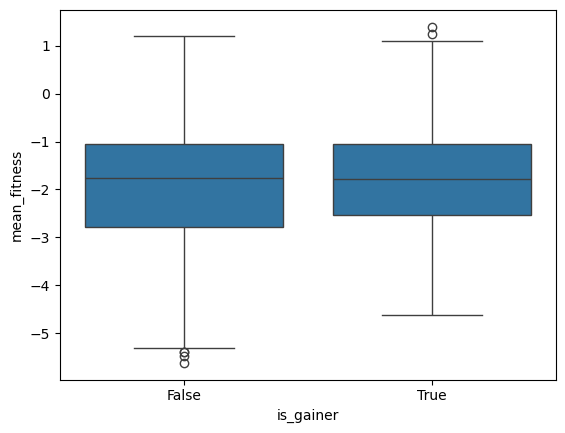

In [152]:
sns.boxplot(x='is_gainer', y='mean_fitness', data=total_data)

In [ ]:
sns.boxplot(x='rate_cat_ns', y='mean_fitness', data=total_data)

## Logistic regression

Category ~ scale(AverageDeltaFitness) + scale(FractionOfLosers(OR G/C content in the first two positions of codons))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from eli5 import show_weights

In [141]:
X = total_data[['mean_fitness', 'is_gainer']]
y = total_data['rate_cat_ns'].round().astype(int)

scaler = StandardScaler()
X['mean_fitness'] = scaler.fit_transform(X[['mean_fitness']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4235)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.69      0.54      0.60       347
           2       0.56      0.68      0.61       776
           3       0.43      0.39      0.41       523
           4       0.48      0.45      0.47       412
           5       0.00      0.00      0.00         5

    accuracy                           0.53      2063
   macro avg       0.43      0.41      0.42      2063
weighted avg       0.53      0.53      0.53      2063

Confusion Matrix:
 [[186 159   2   0   0]
 [ 80 525 127  44   0]
 [  3 165 205 150   0]
 [  1  85 140 186   0]
 [  0   0   0   5   0]]


/home/kpotoh/miniforge3/envs/shift/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kpotoh/miniforge3/envs/shift/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kpotoh/miniforge3/envs/shift/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [129]:
show_weights(model, feature_names=X.columns.tolist(), target_names={1: 'cat1', 2: 'cat2', 3: 'cat3', 4: 'cat4', 5: 'cat5'})

## Linear regression

Category ~ scale(AverageDeltaFitness) + scale(FractionOfLosers(OR G/C content in the first two positions of codons))

In [124]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [148]:
X = total_data[['mean_fitness', 'is_gainer']]
y = total_data['rate_cat_ns']

scaler = StandardScaler()
X['mean_fitness'] = scaler.fit_transform(X[['mean_fitness']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4235)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R^2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R^2 Score: 0.5494446586595176
Mean Squared Error: 0.4187217760644912


In [149]:
show_weights(model, feature_names=X.columns.tolist())

Weight?,Feature
+2.659,<BIAS>
+0.696,mean_fitness
-0.363,is_gainer


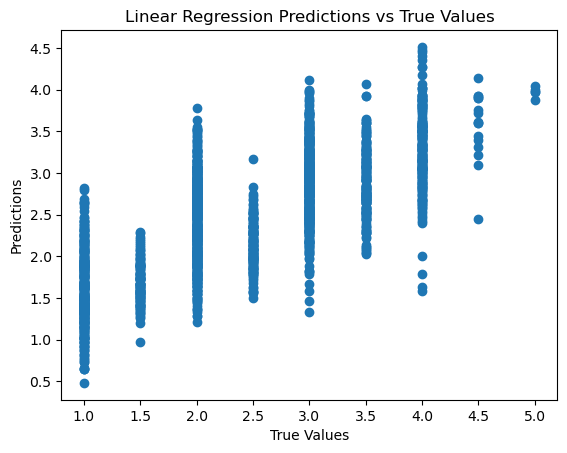

In [150]:
plt.scatter(y_test, y_pred)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Linear Regression Predictions vs True Values')
plt.show()

Conclusion: 

1) if the gainer (reference) in the site ==> site is more conservative
2) if mean fitness of site is higher ==> site is more variable

Important: `is_gainer` and `mean_fitness` are independent variables (no correlation between them).